In [ ]:
from scipy.interpolate import interp1d
import os
import pandas as pd
import numpy as np
import seaborn as sns
import calendar 
import re
from typing import List, Final
import requests
import time
import re
import matplotlib.pyplot as plt
import statsmodels.api as sm
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from scipy.stats import ttest_1samp, kruskal
import scikit_posthocs as sp

sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['figure.dpi'] = 100

SIG_LEVEL: Final[float] = 0.05

In [5]:
asset_info_map = {
    # --- Native LRTs --- 
    'wstETH': {
        'underlying_lrt': 'wstETH', 
        'ecosystem': 'Lido', 
        'ecosystem_slug': 'lido'
    },
    'ezETH': {
        'underlying_lrt': 'ezETH', 
        'ecosystem': 'Renzo', 
        'ecosystem_slug': 'renzo'
    },
    'rsETH': {
        'underlying_lrt': 'rsETH', 
        'ecosystem': 'Kelp DAO', 
        'ecosystem_slug': 'kelp'
    },
    'weETH': {
        'underlying_lrt': 'weETH', 
        'ecosystem': 'Ether.fi', 
        'ecosystem_slug': 'ether.fi'
    },
    'uniETH': {
        'underlying_lrt': 'uniETH', 
        'ecosystem': 'Bedrock', 
        'ecosystem_slug': 'bedrock uniETH' 
    },
    'rswETH': {
        'underlying_lrt': 'rswETH', 
        'ecosystem': 'Swell', 
        'ecosystem_slug': 'swell'
    },
    'pufETH': {
        'underlying_lrt': 'pufETH', 
        'ecosystem': 'Puffer Finance', 
        'ecosystem_slug': 'puffer-finance'
    },
    # --- Bridged LRTs (Ecosystem is the Destination Protocol) ---
    'weETHz': {
        'underlying_lrt': 'weETH', 
        'ecosystem': 'Zircuit', 
        'ecosystem_slug': 'zircuit'
    },
    'rsETHz': {
        'underlying_lrt': 'rsETH',  
        'ecosystem': 'Zircuit',
        'ecosystem_slug': 'zircuit'
    },
    'ezETHz': {
        'underlying_lrt': 'ezETH',  
        'ecosystem': 'Zircuit',
        'ecosystem_slug': 'zircuit'
    },
    'weETHk': {
        'underlying_lrt': 'weETH', 
        'ecosystem': 'Karak',    
        'ecosystem_slug': 'karak'
    },
    'weETHs': {
        'underlying_lrt': 'weETH',  
        'ecosystem': 'Swell L2', 
        'ecosystem_slug': 'swell' 
    }
}


new_data_dir = 'new_data'
sns.set_theme(style="whitegrid")


def load_and_prepare_pendle_file(filepath: str, asset_name_from_parser: str, chain_from_parser: str, 
                                 tenor_month_from_parser: str, tenor_year_from_parser: str,
                                 expected_apy_cols: List[str] | None = None) -> pd.DataFrame | None:
    """
    Loads and preprocesses a single Pendle data CSV.
    Converts APYs to decimal if they appear to be percentages.
    Resamples to daily frequency, taking the last observation of the day.
    """
    if expected_apy_cols is None:
        expected_apy_cols = ['impliedApy', 'underlyingApy1DMA', 'underlyingApy7DMA']

    try:
        df = pd.read_csv(filepath)
        if 'time' not in df.columns:
            print(f"  Warning: 'time' column not found in {filepath}. Skipping.")
            return None
        
        df['time_cleaned'] = df['time'].astype(str).str.replace(r'GMT.*$', '', regex=True).str.strip()
        df['datetime'] = pd.to_datetime(df['time_cleaned'], errors='coerce')
        df.dropna(subset=['datetime'], inplace=True)
        if df.empty:
            print(f"  Warning: No valid datetime entries in {filepath} after cleaning. Skipping.")
            return None
        df = df.set_index('datetime')
        
        rename_map = {}
        final_cols_map = {} # Maps generic key to actual column name in df after rename
        if 'impliedApy' in df.columns and 'impliedApy' in expected_apy_cols:
            rename_map['impliedApy'] = 'implied_apy'
            final_cols_map['implied_apy'] = 'implied_apy'
        if 'underlyingApy1DMA' in df.columns and 'underlyingApy1DMA' in expected_apy_cols:
            rename_map['underlyingApy1DMA'] = 'underlying_apy_1dma'
            final_cols_map['underlying_apy_1dma'] = 'underlying_apy_1dma'
        if 'underlyingApy7DMA' in df.columns and 'underlyingApy7DMA' in expected_apy_cols:
            rename_map['underlyingApy7DMA'] = 'underlying_apy_7dma'
            final_cols_map['underlying_apy_7dma'] = 'underlying_apy_7dma'
        
        df.rename(columns=rename_map, inplace=True)

        for generic_key, actual_col_name in final_cols_map.items():
            if actual_col_name in df.columns:
                df[actual_col_name] = pd.to_numeric(df[actual_col_name], errors='coerce')
                # Ensure APYs are decimal (e.g., 0.05 for 5%)
                mean_val = df[actual_col_name].abs().mean()
                if not pd.isna(mean_val) and mean_val > 1.0 and mean_val != 0:
                    print(f"  Converting {actual_col_name} in {filepath} from % to decimal.")
                    df[actual_col_name] /= 100.0
            else:
                print(f"  Warning: Expected APY column '{generic_key}' (mapped to '{actual_col_name}') not found in {filepath}")
                
        daily_df = df.resample('D').last()
        daily_df.dropna(how='all', inplace=True)

        if daily_df.empty:
            print(f"  Warning: No data after resampling for {filepath}")
            return None

        daily_df['protocol_asset_raw'] = asset_name_from_parser 
        daily_df['chain'] = chain_from_parser
        daily_df['tenor_month_parsed'] = tenor_month_from_parser # Store parsed month
        daily_df['tenor_year_parsed'] = tenor_year_from_parser   # Store parsed year
        daily_df['tenor_str'] = f"{tenor_month_from_parser}{tenor_year_from_parser}"
        
        month_map = {'Jan': 1, 'Feb': 2, 'Mar': 3, 'Apr': 4, 'May': 5, 'Jun': 6, 
                     'Jul': 7, 'Aug': 8, 'Sep': 9, 'Oct': 10, 'Nov': 11, 'Dec': 12}
        try:
            year_full = int(f"20{tenor_year_from_parser}")
            month_num = month_map[tenor_month_from_parser]
            last_day = calendar.monthrange(year_full, month_num)[1]
            expiry_date_str = f"{year_full}-{month_num:02d}-{last_day:02d}"
            expiry_date = pd.to_datetime(expiry_date_str)
            daily_df['ttm_days'] = (expiry_date - daily_df.index).days
            daily_df['ttm_years'] = np.maximum(0, daily_df['ttm_days'] / 365.25)
        except (ValueError, KeyError) as e_ttm:
             print(f"  Could not parse expiry for TTM for {filepath} ({tenor_month_from_parser}{tenor_year_from_parser}): {e_ttm}. TTM will be NaN.")
             daily_df['ttm_years'] = np.nan

        cols_to_keep = ['implied_apy', 'underlying_apy_1dma', 'underlying_apy_7dma', 'volume', 
                        'protocol_asset_raw', 'chain', 'tenor_str', 'ttm_years']
        final_present_cols = [col for col in cols_to_keep if col in daily_df.columns]
        
        return daily_df[final_present_cols]
    except FileNotFoundError:
        print(f"Error: File not found at {filepath}")
        return None
    except Exception as e:
        print(f"Error processing file {filepath}: {e}")
        return None


def parse_pendle_filename(filename_without_ext: str) -> tuple | None:
    """
    Parses a Pendle filename to extract chain, tenor month, tenor year, and asset name.
    Expected format: CHAIN_MONTHYEAR_ASSET.csv (e.g., ETH_Jun25_weETHs.csv)
                     or CHAIN_MONTHYEAR_ASSET_VARIANT.csv (e.g. ETH_Jun24_weETH_z.csv - less common)
    """
    known_base_assets_with_variants = ["weETH", "rsETH"] # Add others if needed
    
    parts = filename_without_ext.split('_')
    if len(parts) < 3:
        print(f"Warning: Filename '{filename_without_ext}' does not match expected format CHAIN_TENOR_ASSET. Skipping.")
        return None

    chain = parts[0]
    tenor_full = parts[1] # e.g., Jun25, Apr24, Dec24, Oct25
    
    # Extract asset name (can be multiple parts if asset name has underscores)
    asset_parts = parts[2:]
    asset_name = "_".join(asset_parts)

    # Extract month and year from tenor_full
    # Use regex to find the first sequence of letters (month) and then digits (year)
    match = re.match(r"([A-Za-z]+)([0-9]+)", tenor_full)
    if not match:
        print(f"Warning: Could not parse tenor '{tenor_full}' from filename '{filename_without_ext}'. Skipping.")
        return None
        
    tenor_month_str = match.group(1).capitalize() # E.g., Jun, Apr, Dec
    tenor_year_str = match.group(2) # E.g., 25, 24

    # Validate month
    valid_months = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
    if tenor_month_str not in valid_months:
        print(f"Warning: Invalid month '{tenor_month_str}' in filename '{filename_without_ext}'. Skipping.")
        return None
        
    return chain, tenor_month_str, tenor_year_str, asset_name

def fetch_all_tvl_data(asset_map: dict) -> None:
    unique_slugs_to_fetch = {info['ecosystem_slug'] for info in asset_map.values()}
    print(f"Found {len(unique_slugs_to_fetch)} unique protocol slugs to fetch: {sorted(list(unique_slugs_to_fetch))}")

    tvl_dir = 'new_data/tvl/'
    os.makedirs(tvl_dir, exist_ok=True)

    for slug in sorted(list(unique_slugs_to_fetch)):
        print(f"\nProcessing slug: '{slug}'...")
        
        output_filename = os.path.join(tvl_dir, f"{slug}.csv")
        
        if os.path.exists(output_filename):
            print(f"  ...File '{output_filename}' already exists. Skipping download.")
            continue

        try:
            api_url = f"https://api.llama.fi/protocol/{slug}"
            
            response = requests.get(api_url, timeout=30) 
            response.raise_for_status()  
            
            data = response.json()
            
            if 'tvl' in data and isinstance(data['tvl'], list) and data['tvl']:
                tvl_history = data['tvl']
            
                df = pd.DataFrame(tvl_history)
                
                # Check for necessary columns
                if 'date' not in df.columns or 'totalLiquidityUSD' not in df.columns:
                    print(f"  ...Warning: API response for '{slug}' missing expected 'date' or 'totalLiquidityUSD' keys.")
                    continue

                df['time'] = pd.to_datetime(df['date'], unit='s')
                df = df[['time', 'totalLiquidityUSD']].rename(columns={'totalLiquidityUSD': 'tvl'})
                
                df.to_csv(output_filename, index=False)
                print(f"  ...Success! Saved to {output_filename}")
                
            else:
                print(f"  ...Warning: No valid 'tvl' data array found in API response for '{slug}'.")
            
            time.sleep(1.5) 

        except requests.exceptions.HTTPError as err:
            print(f"  ...HTTP Error fetching data for '{slug}': {err}")
        except requests.exceptions.Timeout:
            print(f"  ...Request timed out for '{slug}'.")
        except Exception as e:
            print(f"  ...An unexpected error occurred for '{slug}': {e}")

    print("\n--- TVL Data Fetching Complete ---")


# --- Main Data Loading Loop ---
all_pendle_data_nested = {} # Structure: {'Chain': {'AssetRaw': {'TenorStr': DataFrame}}}
dfs_to_concat = []

if not os.path.isdir(new_data_dir):
    print(f"Directory not found: {new_data_dir}")
else:
    for filename in os.listdir(new_data_dir):
        if filename.endswith(".csv"):
            filepath = os.path.join(new_data_dir, filename)
            filename_no_ext = filename[:-4]
            
            parsed_info = parse_pendle_filename(filename_no_ext)
            if parsed_info:
                chain, tenor_month, tenor_year, asset_name = parsed_info
                
                print(f"Processing: {filename} -> Chain: {chain}, Tenor: {tenor_month}{tenor_year}, Asset: {asset_name}")
                
                df = load_and_prepare_pendle_file(filepath, asset_name, chain, tenor_month, tenor_year)
                
                if df is not None and not df.empty:
                    # Populate the nested dictionary
                    if chain not in all_pendle_data_nested:
                        all_pendle_data_nested[chain] = {}
                    if asset_name not in all_pendle_data_nested[chain]:
                        all_pendle_data_nested[chain][asset_name] = {}
                    
                    tenor_string = f"{tenor_month}{tenor_year}" # e.g. Jun24, Dec25
                    all_pendle_data_nested[chain][asset_name][tenor_string] = df
                    dfs_to_concat.append(df)
                    print(f"  Successfully loaded and stored: {chain} - {asset_name} - {tenor_string}")
                else:
                    print(f"  Skipped storing data for {filename} due to loading/processing issues.")
    if dfs_to_concat:
        master_df = pd.concat(dfs_to_concat, ignore_index=False) 
        master_df.sort_index(inplace=True)
    else :
        master_df = pd.DataFrame()

print("\n--- Summary of Loaded Data Structure ---")
for chain_key, assets_dict in all_pendle_data_nested.items():
    print(f"Chain: {chain_key}")
    for asset_key, tenors_dict in assets_dict.items():
        print(f"  Asset: {asset_key}, Tenors: {list(tenors_dict.keys())}")

Processing: ARB_Apr24_rsETH.csv -> Chain: ARB, Tenor: Apr24, Asset: rsETH
  Successfully loaded and stored: ARB - rsETH - Apr24
Processing: ARB_Apr24_weETH.csv -> Chain: ARB, Tenor: Apr24, Asset: weETH
  Successfully loaded and stored: ARB - weETH - Apr24
Processing: ARB_Dec24_rsETH.csv -> Chain: ARB, Tenor: Dec24, Asset: rsETH
  Successfully loaded and stored: ARB - rsETH - Dec24
Processing: ARB_Dec24_uniETH.csv -> Chain: ARB, Tenor: Dec24, Asset: uniETH
  Successfully loaded and stored: ARB - uniETH - Dec24
Processing: ARB_Dec24_weETH.csv -> Chain: ARB, Tenor: Dec24, Asset: weETH
  Successfully loaded and stored: ARB - weETH - Dec24
Processing: ARB_Jun24_ezETH.csv -> Chain: ARB, Tenor: Jun24, Asset: ezETH
  Successfully loaded and stored: ARB - ezETH - Jun24
Processing: ARB_Jun24_rsETH.csv -> Chain: ARB, Tenor: Jun24, Asset: rsETH
  Successfully loaded and stored: ARB - rsETH - Jun24
Processing: ARB_Jun24_weETH.csv -> Chain: ARB, Tenor: Jun24, Asset: weETH
  Successfully loaded and s

## Processing master_df

In [6]:
def preprocess_master_df(master_df: pd.DataFrame, asset_info_map: dict) -> pd.DataFrame:
    # styETH benchmark APY data
    try: 
        styeth_df = pd.read_csv('new_data/benchmark/ETH_styETH.csv')
        styeth_df['datetime'] = pd.to_datetime(styeth_df['time'])
        styeth_df.set_index('datetime', inplace=True)
        if styeth_df['styeth_apy'].abs().mean() > 1.0:
            styeth_df['styeth_apy'] /= 100.0

        # enrich with styETH APY
        styeth_df.index = styeth_df.index.normalize()
        master_df = master_df.merge(styeth_df, on='datetime', how='left')
    except FileNotFoundError:
        print("Error: File not found for ETH styETH data.")
        master_df['styeth_apy'] = np.nan

    # TVL data 
    tvl_dir = 'new_data/tvl/'
    tvl_data_cache = {}
    unique_slugs = {info['ecosystem_slug'] for info in asset_info_map.values()}
    for slug in unique_slugs:
        filepath = os.path.join(tvl_dir, f"{slug}.csv")
        try:
            tvl_df = pd.read_csv(filepath)
            tvl_df['datetime'] = pd.to_datetime(tvl_df['time']).dt.normalize()
            tvl_data_cache[slug] = tvl_df.set_index('datetime')['tvl']
        except FileNotFoundError:
            print(f"  Warning: TVL file not found for slug '{slug}'.")
        except Exception as e:
            print(f"Error loading TVL file for slug '{slug}': {e}")
    master_df['ecosystem_slug'] = master_df['protocol_asset_raw'].map(
        lambda x: asset_info_map.get(x, {}).get('ecosystem_slug')
    )
    master_df['underlying_lrt'] = master_df['protocol_asset_raw'].map(
        lambda x: asset_info_map.get(x, {}).get('underlying_lrt')
    )
    master_df['lrt_protocol_slug'] = master_df['underlying_lrt'].map(
        lambda x: asset_info_map.get(x, {}).get('ecosystem_slug')
    )
    def get_tvl(row, slug_col_name):
        slug = row[slug_col_name]
        date = row.name.normalize() 
        if pd.isna(slug) or slug not in tvl_data_cache:
            return np.nan
        return tvl_data_cache[slug].get(date, np.nan)
    master_df['tvl_ecosystem'] = master_df.apply(lambda row: get_tvl(row, 'ecosystem_slug'), axis=1)
    master_df['tvl_lrt_protocol'] = master_df.apply(lambda row: get_tvl(row, 'lrt_protocol_slug'), axis=1)

    # Misc preprocessing
    master_df['log_tvl_ecosystem'] = np.log1p(master_df['tvl_ecosystem'])
    master_df['log_tvl_lrt_protocol'] = np.log1p(master_df['tvl_lrt_protocol'])

    # Get benchmark APY and 
    master_df = enrich_with_lrt_spread(master_df)

    
    # Return the preprocessed master df
    return master_df

def enrich_with_lrt_spread(master_df: pd.DataFrame) -> pd.DataFrame:
    wsteth_df = master_df[master_df['protocol_asset_raw'] == 'wstETH'].copy()
    wsteth_by_day = wsteth_df.groupby(wsteth_df.index.date)

    def get_benchmark_apy(target_date, target_ttm, wsteth_groups):
        # ... (rest of the function is the same)
        if target_date not in wsteth_groups.groups:
            return np.nan
        daily_wsteth_data = wsteth_groups.get_group(target_date)
        if len(daily_wsteth_data) < 2:
            return np.nan
        daily_wsteth_data = daily_wsteth_data.sort_values('ttm_years')
        x_ttm = daily_wsteth_data['ttm_years'].values
        y_apy = daily_wsteth_data['implied_apy'].values
        if target_ttm < x_ttm.min() or target_ttm > x_ttm.max():
            return np.nan
        interp_func = interp1d(x_ttm, y_apy, kind='linear', bounds_error=False, fill_value=np.nan)
        return interp_func(target_ttm)

    master_df['benchmark_wsteth_apy'] = master_df.apply(
        lambda row: get_benchmark_apy(row.name.date(), row['ttm_years'], wsteth_by_day),
        axis=1
    )

    master_df['lrt_premium_spread'] = master_df['implied_apy'] - master_df['benchmark_wsteth_apy']
    
    return master_df

In [7]:
master_df = preprocess_master_df(master_df, asset_info_map)
master_df

,implied_apy,underlying_apy_1dma,underlying_apy_7dma,volume,protocol_asset_raw,chain,tenor_str,ttm_years,time,styeth_apy,ecosystem_slug,underlying_lrt,lrt_protocol_slug,tvl_ecosystem,tvl_lrt_protocol,log_tvl_ecosystem,log_tvl_lrt_protocol,benchmark_wsteth_apy,lrt_premium_spread
datetime,,,,,,,,,,,,,,,,,,,
2023-03-24,0.0578,0.0470,0.0544,0.0,wstETH,ETH,Dec24,1.774127,2023-03-24T16:00:00,0.045557,lido,wstETH,lido,1.078251e+10,1.078251e+10,23.101192,23.101192,NaN,NaN
2023-03-25,0.0578,0.0427,0.0126,0.0,wstETH,ETH,Dec24,1.771389,2023-03-25T16:00:00,0.044390,lido,wstETH,lido,1.051246e+10,1.051246e+10,23.075827,23.075827,NaN,NaN
2023-03-26,0.0578,0.0422,0.0186,0.0,wstETH,ETH,Dec24,1.768652,2023-03-26T15:00:00,0.044522,lido,wstETH,lido,1.046300e+10,1.046300e+10,23.071111,23.071111,NaN,NaN
2023-03-27,0.0578,0.0465,0.0252,0.0,wstETH,ETH,Dec24,1.765914,2023-03-27T15:00:00,0.046069,lido,wstETH,lido,1.062623e+10,1.062623e+10,23.086592,23.086592,NaN,NaN
2023-03-28,0.0578,0.0542,0.0463,0.0,wstETH,ETH,Dec24,1.763176,2023-03-28T15:00:00,0.046159,lido,wstETH,lido,1.051743e+10,1.051743e+10,23.076299,23.076299,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-06-23,0.0342,0.0246,0.0267,0.0,rsETH,ARB,Jun25,0.019165,2025-06-23T15:00:00,0.030728,kelp,rsETH,kelp,1.031849e+09,1.031849e+09,20.754618,20.754618,0.0209,0.0133
2025-06-23,0.0951,0.0127,0.0457,0.0,uniETH,ETH,Jun25,0.019165,2025-06-23T15:00:00,0.030728,bedrock uniETH,uniETH,bedrock uniETH,3.266900e+07,3.266900e+07,17.301937,17.301937,0.0209,0.0742
2025-06-23,0.0272,0.0303,0.0282,0.0,wstETH,ETH,Dec25,0.522930,2025-06-23T15:00:00,0.030728,lido,wstETH,lido,2.060379e+10,2.060379e+10,23.748741,23.748741,0.0272,0.0


## Analysis

### Boostrapped wstETH yield curves

In [8]:
master_df.index = pd.to_datetime(master_df.index)
wsteth_df = master_df[master_df['protocol_asset_raw'] == 'wstETH'].copy()
# wsteth_df = wsteth_df[['ttm_years', 'implied_apy']]


wsteth_df['date_only'] = wsteth_df.index.date
tenor_counts_per_day = wsteth_df.groupby('date_only').size().reset_index(name='tenor_count')
sorted_tenor_counts = tenor_counts_per_day.sort_values(by='tenor_count', ascending=False)

print("--- Dates with the Most Available wstETH Tenors ---")
print(sorted_tenor_counts.head(5))


def plot_wsteth_yield_curve(date_str, df):
    # Select data for the specific date
    target_date = pd.to_datetime(date_str).date()
    daily_data = df[df.index.date == target_date].sort_values('ttm_years')

    if len(daily_data) < 2:
        print(f"Not enough data points to plot a curve for {date_str}.")
        return

    # Get x and y values
    x_ttm = daily_data['ttm_years'].values
    y_apy = daily_data['implied_apy'].values

    # Create the interpolation function
    interp_func = interp1d(x_ttm, y_apy, kind='linear', bounds_error=False, fill_value=np.nan)

    # Generate points for a smooth curve plot
    x_smooth = np.linspace(x_ttm.min(), x_ttm.max(), 100)
    y_smooth = interp_func(x_smooth)

    # Create the plot
    plt.figure(figsize=(10, 6))
    sns.set_style("whitegrid")
    
    # Plot the interpolated curve
    plt.plot(x_smooth, y_smooth, label='Interpolated Yield Curve', color='royalblue')
    
    # Plot the actual data points
    plt.scatter(x_ttm, y_apy, color='crimson', zorder=5, label='Actual wstETH Tenor APYs')

    # Formatting
    plt.title(f'wstETH Implied Yield Curve on {date_str}', fontsize=16)
    plt.xlabel('Time to Maturity (Years)', fontsize=12)
    plt.ylabel('Implied APY (%)', fontsize=12)
    plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.2%}'))
    plt.legend()
    plt.grid(True, which='both', linestyle='--', linewidth=0.5)
    plt.show()

--- Dates with the Most Available wstETH Tenors ---
      date_only  tenor_count
703  2025-06-23            3
658  2025-05-09            3
671  2025-05-22            3
670  2025-05-21            3
669  2025-05-20            3


--- Summary Statistics of Yield Curve Slopes ---
count    182.000000
mean       0.009038
std        0.009460
min       -0.058758
25%        0.004341
50%        0.007543
75%        0.014033
max        0.022446
Name: slope, dtype: float64

--- Plotting the Distribution of Slopes ---


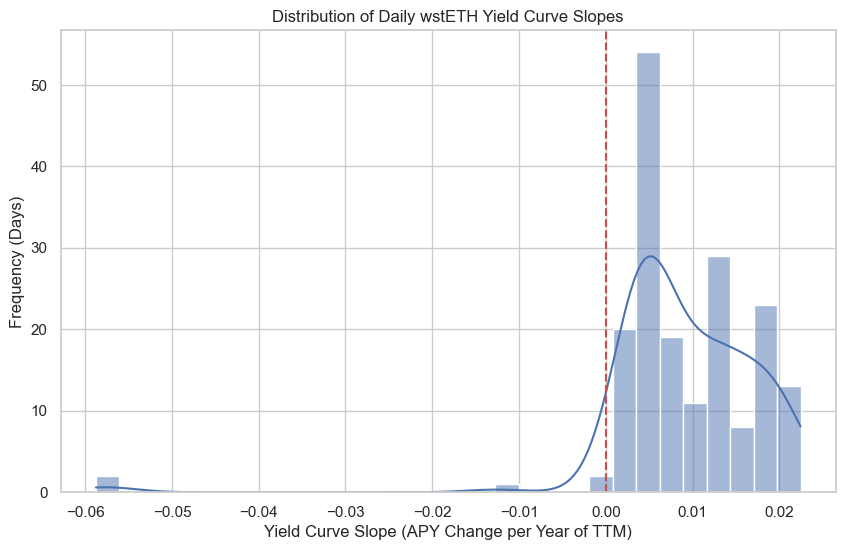

Date with steepest upward slope: 2024-03-18 00:00:00 (Slope: 0.0224)
Date with steepest downward slope: 2024-06-26 00:00:00 (Slope: -0.0588)
Date with flattest slope: 2024-05-24 00:00:00 (Slope: -0.0002)
One-Sample T-test for Yield Curve Slopes:
T-statistic: 12.8886
P-value: 0.0000
The mean slope is statistically significantly different from zero.


In [9]:

curve_slopes = []
valid_dates = []
wsteth_by_day = wsteth_df.groupby('date_only')
for date, group in wsteth_by_day:
    # We need at least 2 points to calculate a slope
    if len(group) >= 2:
        # Reshape data for linear regression
        X = group['ttm_years'].values.reshape(-1, 1)
        y = group['implied_apy'].values
        
        # Fit a linear regression model
        model = LinearRegression()
        model.fit(X, y)
        
        # The slope is the coefficient
        slope = model.coef_[0]
        
        valid_dates.append(date)
        curve_slopes.append(slope)

# Create a new dataframe with the slope information
slopes_df = pd.DataFrame({
    'date': valid_dates,
    'slope': curve_slopes
})
slopes_df['date'] = pd.to_datetime(slopes_df['date'])
slopes_df.set_index('date', inplace=True)

# --- Analyze the Slopes ---
print("--- Summary Statistics of Yield Curve Slopes ---")
print(slopes_df['slope'].describe())

print("\n--- Plotting the Distribution of Slopes ---")
plt.figure(figsize=(10, 6))
sns.histplot(slopes_df['slope'], bins=30, kde=True)
plt.title('Distribution of Daily wstETH Yield Curve Slopes')
plt.xlabel('Yield Curve Slope (APY Change per Year of TTM)')
plt.ylabel('Frequency (Days)')
plt.axvline(0, color='r', linestyle='--')
plt.show()

# Find a date with a steep positive slope
steep_upward_date = slopes_df['slope'].idxmax()
print(f"Date with steepest upward slope: {steep_upward_date} (Slope: {slopes_df.loc[steep_upward_date, 'slope']:.4f})")
# Find a date with a steep negative (inverted) slope
steep_downward_date = slopes_df['slope'].idxmin()
print(f"Date with steepest downward slope: {steep_downward_date} (Slope: {slopes_df.loc[steep_downward_date, 'slope']:.4f})")
# Find a date with a nearly flat slope
flat_date = slopes_df.iloc[(slopes_df['slope']).abs().argsort()[:1]].index[0]
print(f"Date with flattest slope: {flat_date} (Slope: {slopes_df.loc[flat_date, 'slope']:.4f})")

## For plotting the yield curves for visual inspection
# plot_wsteth_yield_curve(str(steep_upward_date), wsteth_df)
# plot_wsteth_yield_curve(str(steep_downward_date), wsteth_df)
# plot_wsteth_yield_curve('2025-06-23', wsteth_df)


slopes = slopes_df['slope'].dropna()
t_statistic, p_value = ttest_1samp(slopes, 0)
print(f"One-Sample T-test for Yield Curve Slopes:")
print(f"T-statistic: {t_statistic:.4f}")
print(f"P-value: {p_value:.4f}")
if p_value < SIG_LEVEL:
    print("The mean slope is statistically significantly different from zero.")
else:
    print("The mean slope is not statistically significantly different from zero.")

### Futures market efficency, pricing of poins: styETH vs Lido wstETH

In [10]:
if 'yield_curve_slope' not in wsteth_df.columns:
    wsteth_df = wsteth_df.merge(slopes_df, left_index=True, right_index=True, how='left')
    wsteth_df.rename(columns={'slope': 'yield_curve_slope'}, inplace=True)
wsteth_df.head(3)

,implied_apy,underlying_apy_1dma,underlying_apy_7dma,volume,protocol_asset_raw,chain,tenor_str,ttm_years,time,styeth_apy,...,underlying_lrt,lrt_protocol_slug,tvl_ecosystem,tvl_lrt_protocol,log_tvl_ecosystem,log_tvl_lrt_protocol,benchmark_wsteth_apy,lrt_premium_spread,date_only,yield_curve_slope
2023-03-24,0.0578,0.0470,0.0544,0.0,wstETH,ETH,Dec24,1.774127,2023-03-24T16:00:00,0.045557,...,wstETH,lido,1.078251e+10,1.078251e+10,23.101192,23.101192,NaN,NaN,2023-03-24,NaN
2023-03-25,0.0578,0.0427,0.0126,0.0,wstETH,ETH,Dec24,1.771389,2023-03-25T16:00:00,0.044390,...,wstETH,lido,1.051246e+10,1.051246e+10,23.075827,23.075827,NaN,NaN,2023-03-25,NaN
2023-03-26,0.0578,0.0422,0.0186,0.0,wstETH,ETH,Dec24,1.768652,2023-03-26T15:00:00,0.044522,...,wstETH,lido,1.046300e+10,1.046300e+10,23.071111,23.071111,NaN,NaN,2023-03-26,NaN


#### Lido wstETH spot - styETH benchmark comparison

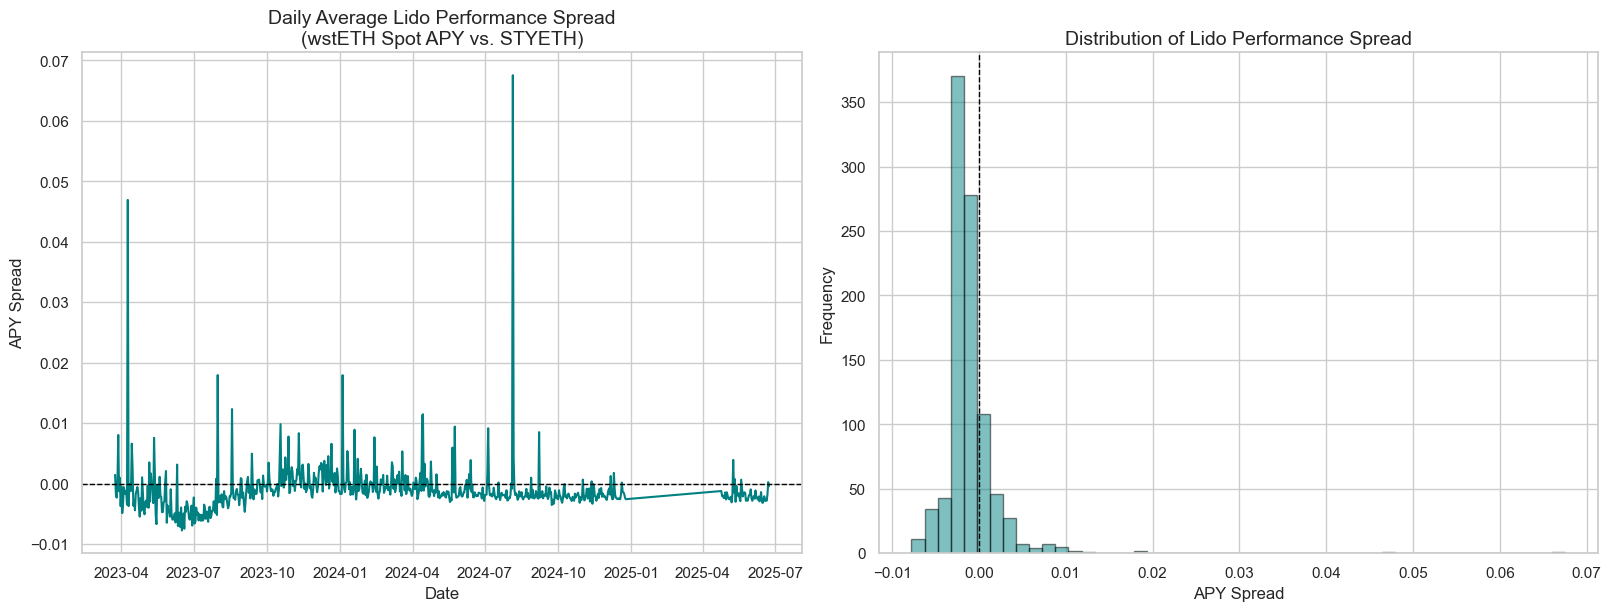

count    947.000000
mean      -0.001099
std        0.003715
min       -0.007760
25%       -0.002395
50%       -0.001661
75%       -0.000492
max        0.067554
Name: lido_performance_spread, dtype: float64
Average Spread (Lido wstETH spot - styETH benchmark): -10.99 bps


In [11]:
wsteth_df['lido_performance_spread'] = wsteth_df['underlying_apy_1dma'] - wsteth_df['styeth_apy']
fig, axs = plt.subplots(1, 2, figsize=(16, 6), constrained_layout=True)
daily_avg = wsteth_df.groupby(wsteth_df.index.date)['lido_performance_spread'].mean()
axs[0].plot(daily_avg.index, daily_avg, color='teal')
axs[0].axhline(0, color='black', linestyle='--', linewidth=1)
axs[0].set_title('Daily Average Lido Performance Spread\n(wstETH Spot APY vs. STYETH)', fontsize=14)
axs[0].set_ylabel('APY Spread')
axs[0].set_xlabel('Date')
axs[1].hist(
    wsteth_df['lido_performance_spread'],
    bins=50,
    alpha=0.5,
    color='teal',
    edgecolor='black'
)
axs[1].axvline(0, color='black', linestyle='--', linewidth=1)
axs[1].set_title('Distribution of Lido Performance Spread', fontsize=14)
axs[1].set_xlabel('APY Spread')
axs[1].set_ylabel('Frequency')
plt.show()
print(wsteth_df['lido_performance_spread'].describe())
print(f"Average Spread (Lido wstETH spot - styETH benchmark): {wsteth_df['lido_performance_spread'].mean() * 10000:.2f} bps")


## Plot all asset spreads on one graph
# plt.figure(figsize=(12, 6))
# for asset in master_df['protocol_asset_raw'].unique():
#     if asset == 'wstETH':
#         continue
#     asset_df = master_df[master_df['protocol_asset_raw'] == asset].copy()
#     asset_df['spread'] = asset_df['underlying_apy_1dma'] - asset_df['styeth_apy']
#     sns.lineplot(data=asset_df, x=asset_df.index, y='spread', label=asset)
#     print(f'Average Spread for {asset}: {asset_df["spread"].mean() * 10000:.2f} bps')
# plt.axhline(0, color='black', linestyle='--', linewidth=1)
# plt.title(f'{asset} Spread vs. wstETH Benchmark', fontsize=16)
# plt.ylabel('Spread (APY)')
# plt.xlabel('Date')
# plt.legend()
# plt.show()

#### Lido wstETH forward premium vs. term slope regression

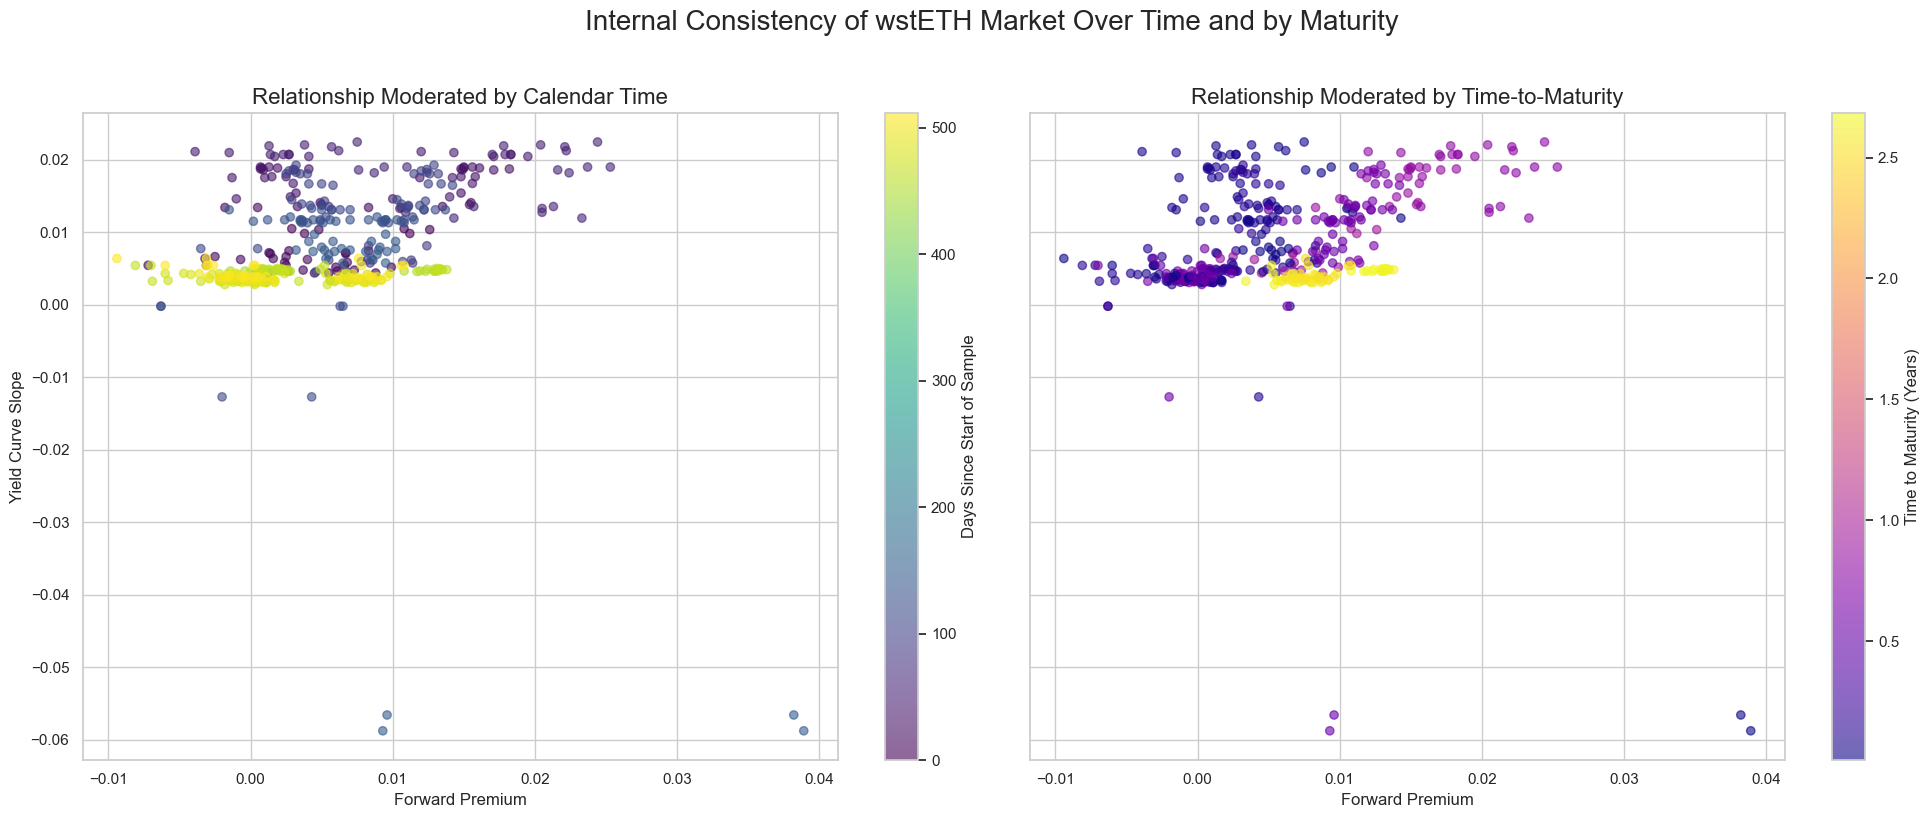

In [12]:
wsteth_df['forward_premium'] = wsteth_df['implied_apy'] - wsteth_df['underlying_apy_1dma']
plot_df = wsteth_df[['forward_premium', 'yield_curve_slope', 'ttm_years']].dropna()
plot_df['time_numeric'] = (plot_df.index - plot_df.index.min()).days


# --- Create the 2x1 Subplot Figure ---
fig, axes = plt.subplots(1, 2, figsize=(20, 8), sharey=True)
fig.suptitle('Internal Consistency of wstETH Market Over Time and by Maturity', fontsize=20, y=1.02)
sns.set_theme(style="whitegrid")

# Colored by Calendar Time 
scatter1 = axes[0].scatter(
    data=plot_df,
    x='forward_premium',
    y='yield_curve_slope',
    c='time_numeric',
    cmap='viridis',
    alpha=0.6
)
fig.colorbar(scatter1, ax=axes[0], label='Days Since Start of Sample')
axes[0].set_title('Relationship Moderated by Calendar Time', fontsize=16)
axes[0].set_xlabel('Forward Premium', fontsize=12)
axes[0].set_ylabel('Yield Curve Slope', fontsize=12)
axes[0].grid(True)

# Colored by Time-to-Maturity 
scatter2 = axes[1].scatter(
    data=plot_df,
    x='forward_premium',
    y='yield_curve_slope',
    c='ttm_years',
    cmap='plasma',
    alpha=0.6
)
fig.colorbar(scatter2, ax=axes[1], label='Time to Maturity (Years)')
axes[1].set_title('Relationship Moderated by Time-to-Maturity', fontsize=16)
axes[1].set_xlabel('Forward Premium', fontsize=12)
axes[1].grid(True)

plt.tight_layout()
plt.show()

OLS Regression Results (Standardized Predictors)
                            OLS Regression Results                            
Dep. Variable:      yield_curve_slope   R-squared:                       0.221
Model:                            OLS   Adj. R-squared:                  0.216
Method:                 Least Squares   F-statistic:                     39.93
Date:                Thu, 03 Jul 2025   Prob (F-statistic):           1.00e-22
Time:                        09:29:08   Log-Likelihood:                 1456.4
No. Observations:                 425   AIC:                            -2905.
Df Residuals:                     421   BIC:                            -2889.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
con

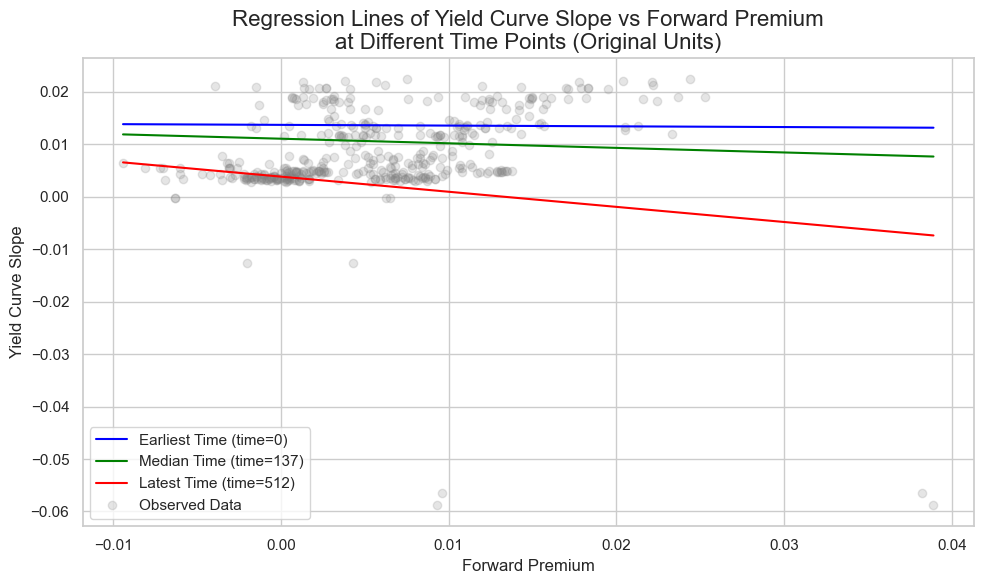

In [13]:
regression_df = wsteth_df[['forward_premium', 'yield_curve_slope']].dropna().copy()
regression_df['time'] = (regression_df.index - regression_df.index.min()).days

scaler = StandardScaler()
predictors = regression_df[['forward_premium', 'time']]
predictors_scaled = scaler.fit_transform(predictors)

interaction_scaled = predictors_scaled[:, 0] * predictors_scaled[:, 1]

X_scaled = np.column_stack([
    predictors_scaled[:, 0],  
    predictors_scaled[:, 1], 
    interaction_scaled        
])
X_scaled = sm.add_constant(X_scaled)
y = regression_df['yield_curve_slope']
model = sm.OLS(y, X_scaled).fit()

print("OLS Regression Results (Standardized Predictors)")
print(model.summary())

# standardized_x = (x - mean) / std
premium_mean = scaler.mean_[0]
premium_std = scaler.scale_[0]
time_mean = scaler.mean_[1]
time_std = scaler.scale_[1]
b0 = model.params.iloc[0]
b1 = model.params.iloc[1]
b2 = model.params.iloc[2]
b3 = model.params.iloc[3]

x_vals_original = np.linspace(
    regression_df['forward_premium'].min(),
    regression_df['forward_premium'].max(),
    100
)

time_min_original = regression_df['time'].min()
time_med_original = regression_df['time'].median()
time_max_original = regression_df['time'].max()
time_min_std = (time_min_original - time_mean) / time_std
time_med_std = (time_med_original - time_mean) / time_std
time_max_std = (time_max_original - time_mean) / time_std

y_min = []
y_med = []
y_max = []
for x_orig in x_vals_original:
    x_std = (x_orig - premium_mean) / premium_std
    y_min.append(
        b0 + b1 * x_std + b2 * time_min_std + b3 * (x_std * time_min_std)
    )
    y_med.append(
        b0 + b1 * x_std + b2 * time_med_std + b3 * (x_std * time_med_std)
    )
    y_max.append(
        b0 + b1 * x_std + b2 * time_max_std + b3 * (x_std * time_max_std)
    )

y_min = np.array(y_min)
y_med = np.array(y_med)
y_max = np.array(y_max)

plt.figure(figsize=(10, 6))
plt.plot(x_vals_original, y_min, label=f'Earliest Time (time={int(time_min_original)})', color='blue')
plt.plot(x_vals_original, y_med, label=f'Median Time (time={int(time_med_original)})', color='green')
plt.plot(x_vals_original, y_max, label=f'Latest Time (time={int(time_max_original)})', color='red')
plt.scatter(
    regression_df['forward_premium'],
    regression_df['yield_curve_slope'],
    alpha=0.2,
    color='gray',
    label='Observed Data'
)
plt.title('Regression Lines of Yield Curve Slope vs Forward Premium\nat Different Time Points (Original Units)', fontsize=16)
plt.xlabel('Forward Premium', fontsize=12)
plt.ylabel('Yield Curve Slope', fontsize=12)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

#### Realized vs Implied yield as a measure of 'market efficiency'

Analyzing Market Efficiency for: wstETH
Found 4 matured tenors to analyze: ['Dec24', 'Jun24', 'Jun25', 'Mar24']
Analysis for wstETH based on 823 total prediction points.


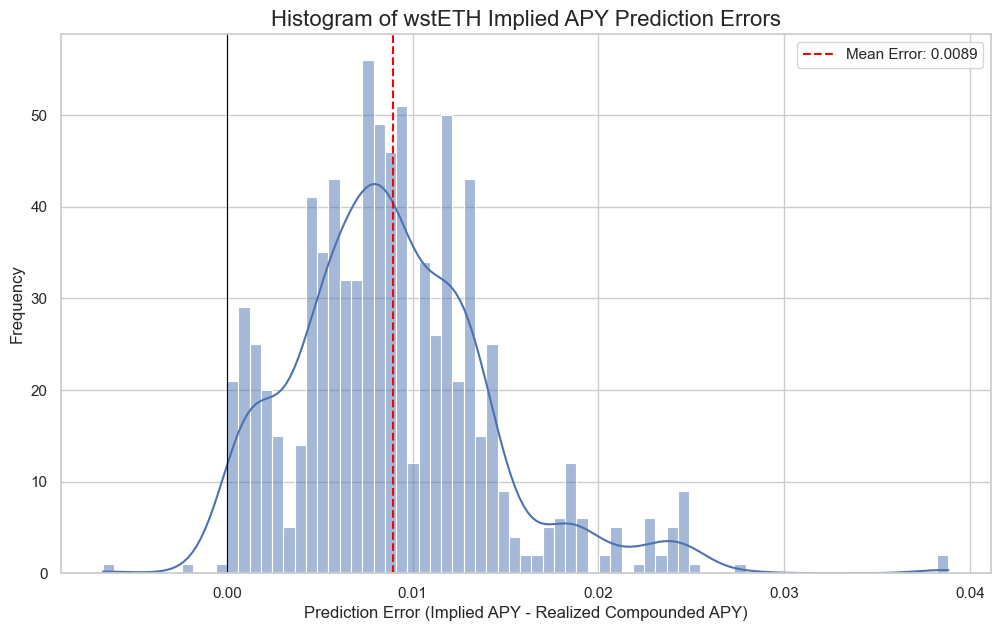

Market Efficiency Summary for wstETH
count    823.000000
mean       0.008913
std        0.005383
min       -0.006675
25%        0.005317
50%        0.008402
75%        0.011990
max        0.038843
Name: prediction_error, dtype: float64
One-sample t-test (H0: Mean Error = 0) for {asset_name}:
t-statistic: 47.5055, p-value: 0.0000


In [14]:
def analyze_lrt_market_efficiency(asset_df: pd.DataFrame, asset_name: str, spot_apy_col: str = 'underlying_apy_1dma', do_output: bool = True):
    print(f"Analyzing Market Efficiency for: {asset_name}")
    asset_df = asset_df.sort_index()
    daily_spot_apy_series = asset_df.groupby(asset_df.index.date)[spot_apy_col].mean()
    daily_spot_apy_series.index = pd.to_datetime(daily_spot_apy_series.index)

    all_tenors = asset_df['tenor_str'].unique()
    matured_tenors = [t for t in all_tenors if (pd.to_datetime(t, format='%b%y') + pd.tseries.offsets.MonthEnd(1)) < pd.Timestamp.now()]
    
    if not matured_tenors:
        print(f"No matured tenors found for {asset_name}. Cannot proceed.")
        return None

    print(f"Found {len(matured_tenors)} matured tenors to analyze: {sorted(matured_tenors)}")
    
    all_results = []
    for tenor in matured_tenors:
        tenor_df = asset_df[asset_df['tenor_str'] == tenor].copy()
        expiry_date = pd.to_datetime(tenor, format='%b%y') + pd.tseries.offsets.MonthEnd(1)
        
        realized_yields = {}
        for prediction_date, row in tenor_df.iterrows():
            implied_apy_prediction = row['implied_apy']
            
            start_period = prediction_date + pd.Timedelta(days=1)
            end_period = expiry_date
            
            if start_period > end_period: 
                continue
            
            future_spot_apys = daily_spot_apy_series.loc[start_period:end_period]
            days_to_maturity = (end_period - prediction_date).days
            
            if not future_spot_apys.empty and days_to_maturity > 0:
                daily_returns = 1 + future_spot_apys / 365.25
                cumulative_return = np.prod(daily_returns)
                annualized_realized_yield = (cumulative_return ** (365.25 / days_to_maturity)) - 1
                
                prediction_error = implied_apy_prediction - annualized_realized_yield
                
                realized_yields[prediction_date] = annualized_realized_yield
                all_results.append({'prediction_error': prediction_error})

        tenor_df['realized_apy'] = tenor_df.index.map(realized_yields)
        tenor_df.dropna(subset=['realized_apy', 'implied_apy'], inplace=True)
        # if not tenor_df.empty:
        #     tenor_df['prediction_error'] = tenor_df['realized_apy'] - tenor_df['implied_apy']
            
        #     print(f"\n--- Analyzing Tenor: {tenor} ---")
        #     print(f"Summary Statistics of Market Prediction Error for Tenor '{tenor}':")
        #     print(tenor_df['prediction_error'].describe())
            
        #     stat, p_value = ttest_1samp(tenor_df['prediction_error'], 0)
        #     print(f"T-test (Mean Error vs. 0) for '{tenor}': P-value = {p_value:.4f}")
            
        #     # Plotting code remains the same...
        #     plt.figure()
        #     sns.histplot(tenor_df['prediction_error'], bins=20, kde=True)
        #     plt.title(f'Distribution of Prediction Errors for Tenor {tenor}')
        #     plt.xlabel('Prediction Error (Realized - Implied APY)')
        #     plt.axvline(0, color='r', linestyle='--')
        #     plt.show()

    if not all_results:
        print(f"Could not calculate prediction errors for {asset_name}.")
        return None

    efficiency_df = pd.DataFrame(all_results)
    
    if do_output:
        print(f"Analysis for {asset_name} based on {len(efficiency_df)} total prediction points.")
        plt.figure(figsize=(12, 7))
        sns.histplot(data=efficiency_df, x='prediction_error', bins=75, kde=True)
        mean_error = efficiency_df['prediction_error'].mean()
        plt.axvline(mean_error, color='red', linestyle='--', label=f'Mean Error: {mean_error:.4f}')
        plt.axvline(0, color='black', linestyle='-', linewidth=0.8)
        plt.title(f'Histogram of {asset_name} Implied APY Prediction Errors', fontsize=16)
        plt.xlabel('Prediction Error (Implied APY - Realized Compounded APY)')
        plt.ylabel('Frequency')
        plt.legend()
        plt.show()
        
        print(f'Market Efficiency Summary for {asset_name}')
        print(efficiency_df['prediction_error'].describe())
        
        t_stat, p_value = ttest_1samp(efficiency_df['prediction_error'].dropna(), 0)
        print('One-sample t-test (H0: Mean Error = 0) for {asset_name}:')
        print(f't-statistic: {t_stat:.4f}, p-value: {p_value:.4f}')
    return efficiency_df


wsteth_efficiency_results = analyze_lrt_market_efficiency(wsteth_df, 'wstETH')

Analyzing Market Efficiency for: wstETH
Found 4 matured tenors to analyze: ['Dec24', 'Jun24', 'Jun25', 'Mar24']
Analyzing Market Efficiency for: ezETH
Found 4 matured tenors to analyze: ['Apr24', 'Dec24', 'Jun24', 'Sep24']
Analyzing Market Efficiency for: rsETH
Found 5 matured tenors to analyze: ['Apr24', 'Dec24', 'Jun24', 'Jun25', 'Sep24']
Analyzing Market Efficiency for: weETH
Found 6 matured tenors to analyze: ['Apr24', 'Aug24', 'Dec24', 'Jun24', 'Jun25', 'Sep24']
Analyzing Market Efficiency for: uniETH
Found 4 matured tenors to analyze: ['Dec24', 'Jun24', 'Jun25', 'Sep24']
Analyzing Market Efficiency for: weETHz
Found 1 matured tenors to analyze: ['Jun24']
Analyzing Market Efficiency for: rsETHz
Found 2 matured tenors to analyze: ['Aug24', 'Jun24']
Analyzing Market Efficiency for: ezETHz
Found 1 matured tenors to analyze: ['Jun24']
Analyzing Market Efficiency for: rswETH
Found 5 matured tenors to analyze: ['Dec24', 'Jul24', 'Jun24', 'Jun25', 'Sep24']
Analyzing Market Efficiency for

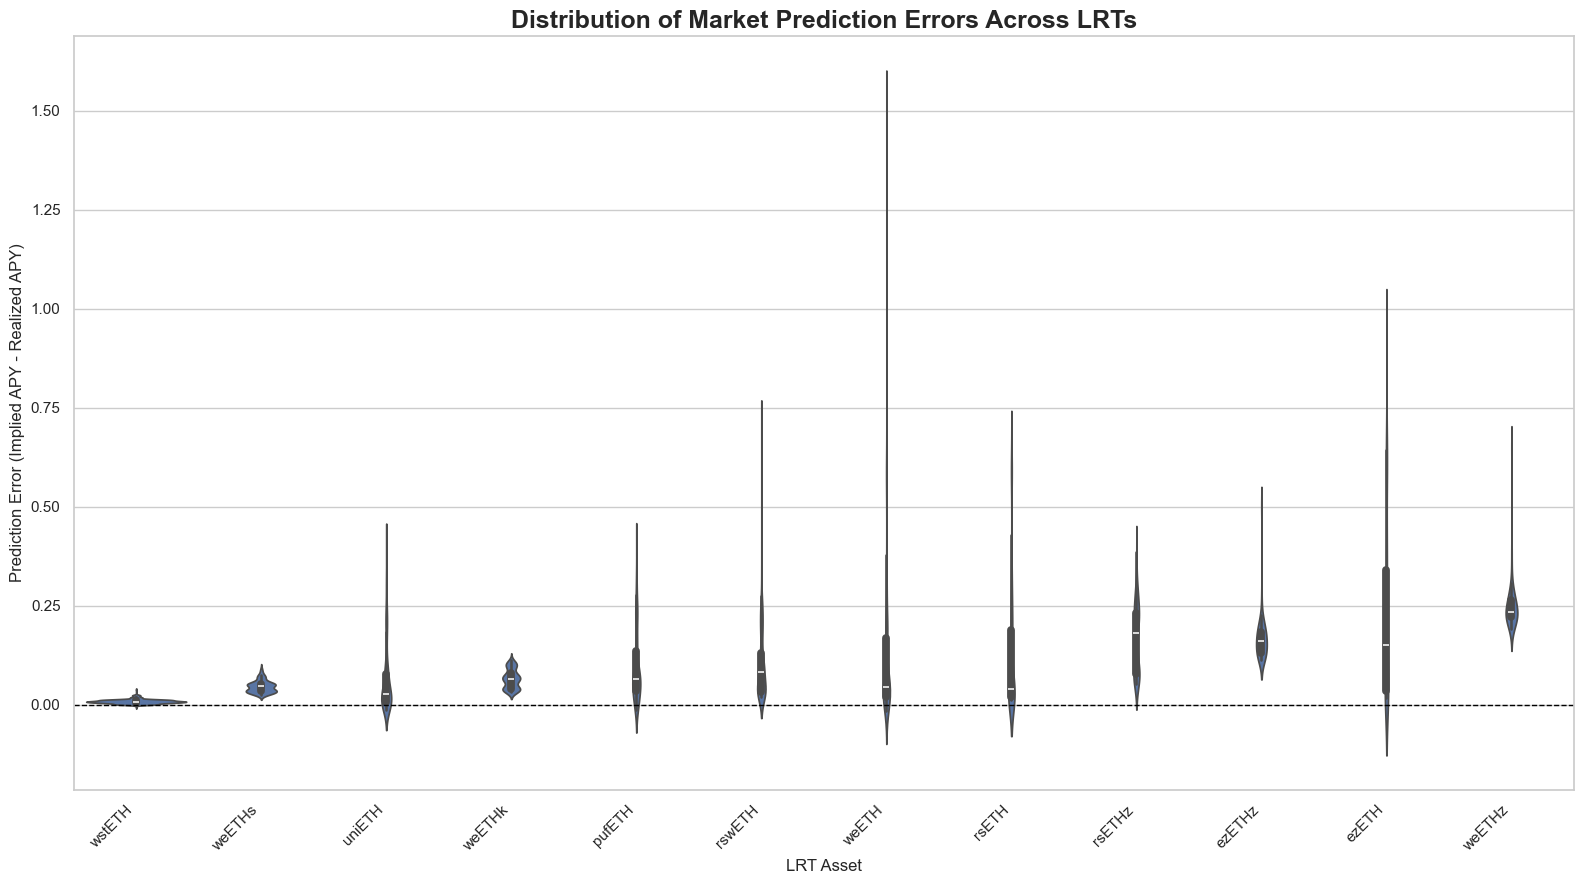

In [15]:
all_efficiency_results = []
for asset_name in master_df['protocol_asset_raw'].unique():
    asset_df = master_df[master_df['protocol_asset_raw'] == asset_name].copy()
    if not asset_df.empty:
        efficiency_results_df = analyze_lrt_market_efficiency(asset_df, asset_name, do_output=False)
        if efficiency_results_df is not None:
            efficiency_results_df['asset'] = asset_name 
            all_efficiency_results.append(efficiency_results_df)

if all_efficiency_results:
    overall_efficiency_df = pd.concat(all_efficiency_results)

if 'overall_efficiency_df' in locals() and not overall_efficiency_df.empty:
    plt.figure(figsize=(16, 9))
    order = overall_efficiency_df.groupby('asset')['prediction_error'].mean().sort_values().index
    sns.violinplot(data=overall_efficiency_df, x='asset', y='prediction_error', order=order)
    plt.axhline(0, color='black', linestyle='--', linewidth=1)
    plt.title('Distribution of Market Prediction Errors Across LRTs', fontsize=18, fontweight='bold')
    plt.xlabel('LRT Asset')
    plt.ylabel('Prediction Error (Implied APY - Realized APY)')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

### LRT premium analysis (implied apy - implied apy of wsteth interpolated benchmark)

### NEW

Analysis will be performed on 1711 data points.

Generating Plot 1: LPS by TVL Quantile...


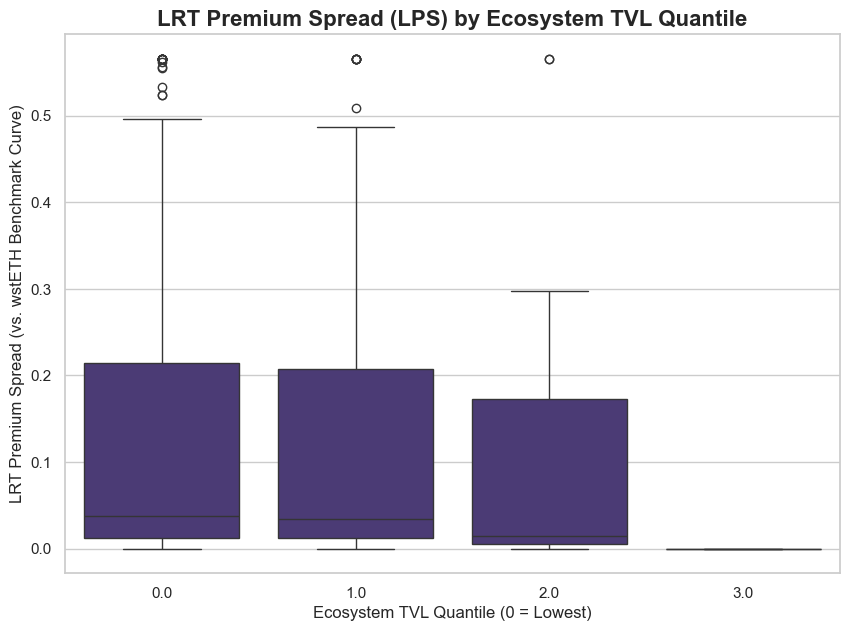


--- Statistical Analysis for LPS by TVL Quantile ---
Kruskal-Wallis H-test statistic: 737.8591, p-value: 1.2956e-159

Conover's Post-Hoc Test (p-values):
|          |       0.0 |       1.0 |       2.0 |       3.0 |
|---------:|----------:|----------:|----------:|----------:|
| 0.00e+00 | 1.00e+00  | 2.44e-01  | 1.10e-21  | 2.91e-191 |
| 1.00e+00 | 2.44e-01  | 1.00e+00  | 1.19e-14  | 6.26e-163 |
| 2.00e+00 | 1.10e-21  | 1.19e-14  | 1.00e+00  | 1.37e-110 |
| 3.00e+00 | 2.91e-191 | 6.26e-163 | 1.37e-110 | 1.00e+00  |

Generating Plot 2: Term Structure of LPS...


ValueError: Could not interpret value `TTM_years` for `x`. An entry with this name does not appear in `data`.

<Figure size 1400x800 with 0 Axes>

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import kruskal
import scikit_posthocs as sp

# --- Assume 'master_df' is the final, fully processed DataFrame from your script ---
# It should contain the crucial 'lrt_premium_spread' column.

# --- Step 1: Prepare the Analysis DataFrame ---
# Create a clean version for analysis by dropping rows where key metrics are missing.
analysis_df = master_df.dropna(subset=['lrt_premium_spread', 'tvl_ecosystem']).copy()

# Create TVL quantiles for grouping.
# This part is crucial and should be done on the analysis_df.
analysis_df['tvl_quantile'] = analysis_df.groupby(analysis_df.index.date)['tvl_ecosystem'].transform(
    lambda x: pd.qcut(x, 4, labels=False, duplicates='drop')
)
analysis_df.dropna(subset=['tvl_quantile'], inplace=True) # Drop rows if quantile could not be assigned

# Winsorize the final spread for cleaner plots
lower_bound = analysis_df['lrt_premium_spread'].quantile(0.01)
upper_bound = analysis_df['lrt_premium_spread'].quantile(0.99)
analysis_df['LPS_winsorized'] = analysis_df['lrt_premium_spread'].clip(lower=lower_bound, upper=upper_bound)

print(f"Analysis will be performed on {len(analysis_df)} data points.")


# --- Step 2: Generate the Core Plots for the Paper ---

# Set plot style
sns.set_theme(style="whitegrid", palette="viridis")
plt.rcParams['figure.figsize'] = (14, 8)
plt.rcParams['figure.dpi'] = 100

# --- Plot 1: LPS by Ecosystem TVL Quantile (Core Result) ---
print("\nGenerating Plot 1: LPS by TVL Quantile...")
plt.figure(figsize=(10, 7))
sns.boxplot(data=analysis_df, x='tvl_quantile', y='LPS_winsorized')
plt.title('LRT Premium Spread (LPS) by Ecosystem TVL Quantile', fontsize=16, fontweight='bold')
plt.xlabel('Ecosystem TVL Quantile (0 = Lowest)')
plt.ylabel('LRT Premium Spread (vs. wstETH Benchmark Curve)')
plt.show()

# --- Statistical Tests for Plot 1 ---
print("\n--- Statistical Analysis for LPS by TVL Quantile ---")
quantiles = [group['LPS_winsorized'].dropna() for name, group in analysis_df.groupby('tvl_quantile')]
kruskal_stat, kruskal_p = kruskal(*quantiles)
print(f"Kruskal-Wallis H-test statistic: {kruskal_stat:.4f}, p-value: {kruskal_p:.4e}")
if kruskal_p < 0.05:
    print("\nConover's Post-Hoc Test (p-values):")
    conover_results = sp.posthoc_conover(analysis_df, val_col='LPS_winsorized', group_col='tvl_quantile')
    print(conover_results.to_markdown(floatfmt=".2e"))


# --- Plot 2: Term Structure of LPS ---
print("\nGenerating Plot 2: Term Structure of LPS...")
plt.figure()
# Sample for readability
sample_df = analysis_df.sample(n=min(5000, len(analysis_df)), random_state=42)
sns.scatterplot(data=sample_df, x='TTM_years', y='LPS_winsorized', hue='tvl_quantile', palette='viridis', alpha=0.5, s=50)
plt.title('Term Structure of LRT Premium Spread (LPS)', fontsize=16, fontweight='bold')
plt.xlabel('Time to Maturity (Years)')
plt.ylabel('LRT Premium Spread (Winsorized)')
plt.legend(title='TVL Quantile')
plt.show()


# --- Plot 3: LPS by LRT Asset ---
print("\nGenerating Plot 3: LPS by LRT Asset...")
plt.figure(figsize=(16, 9))
# Exclude the benchmark itself from this comparative plot
plot_df = analysis_df[analysis_df['protocol_asset_raw'] != 'wstETH']
# Order by median LPS for a cleaner visual
order = plot_df.groupby('protocol_asset_raw')['LPS_winsorized'].median().sort_values().index
sns.violinplot(data=plot_df, x='protocol_asset_raw', y='LPS_winsorized', order=order)
plt.axhline(0, color='black', linestyle='--', linewidth=1)
plt.title('Distribution of LRT Premium Spreads by Asset', fontsize=18, fontweight='bold')
plt.xlabel('LRT Asset')
plt.ylabel('LRT Premium Spread (vs. wstETH Benchmark Curve)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# --- Accompanying Summary Table for Plot 3 ---
print("\n--- Summary Statistics of LRT Premium Spread (LPS) by LRT ---")
lps_summary = analysis_df.groupby('protocol_asset_raw')['lrt_premium_spread'].describe()
# Exclude the benchmark from the summary table as well
print(lps_summary.drop('wstETH', errors='ignore').to_markdown(floatfmt=".4f"))

Starting analysis on 1711 data points.

--- Generating Figure 1: Comparison of Raw APY vs. LPS ---


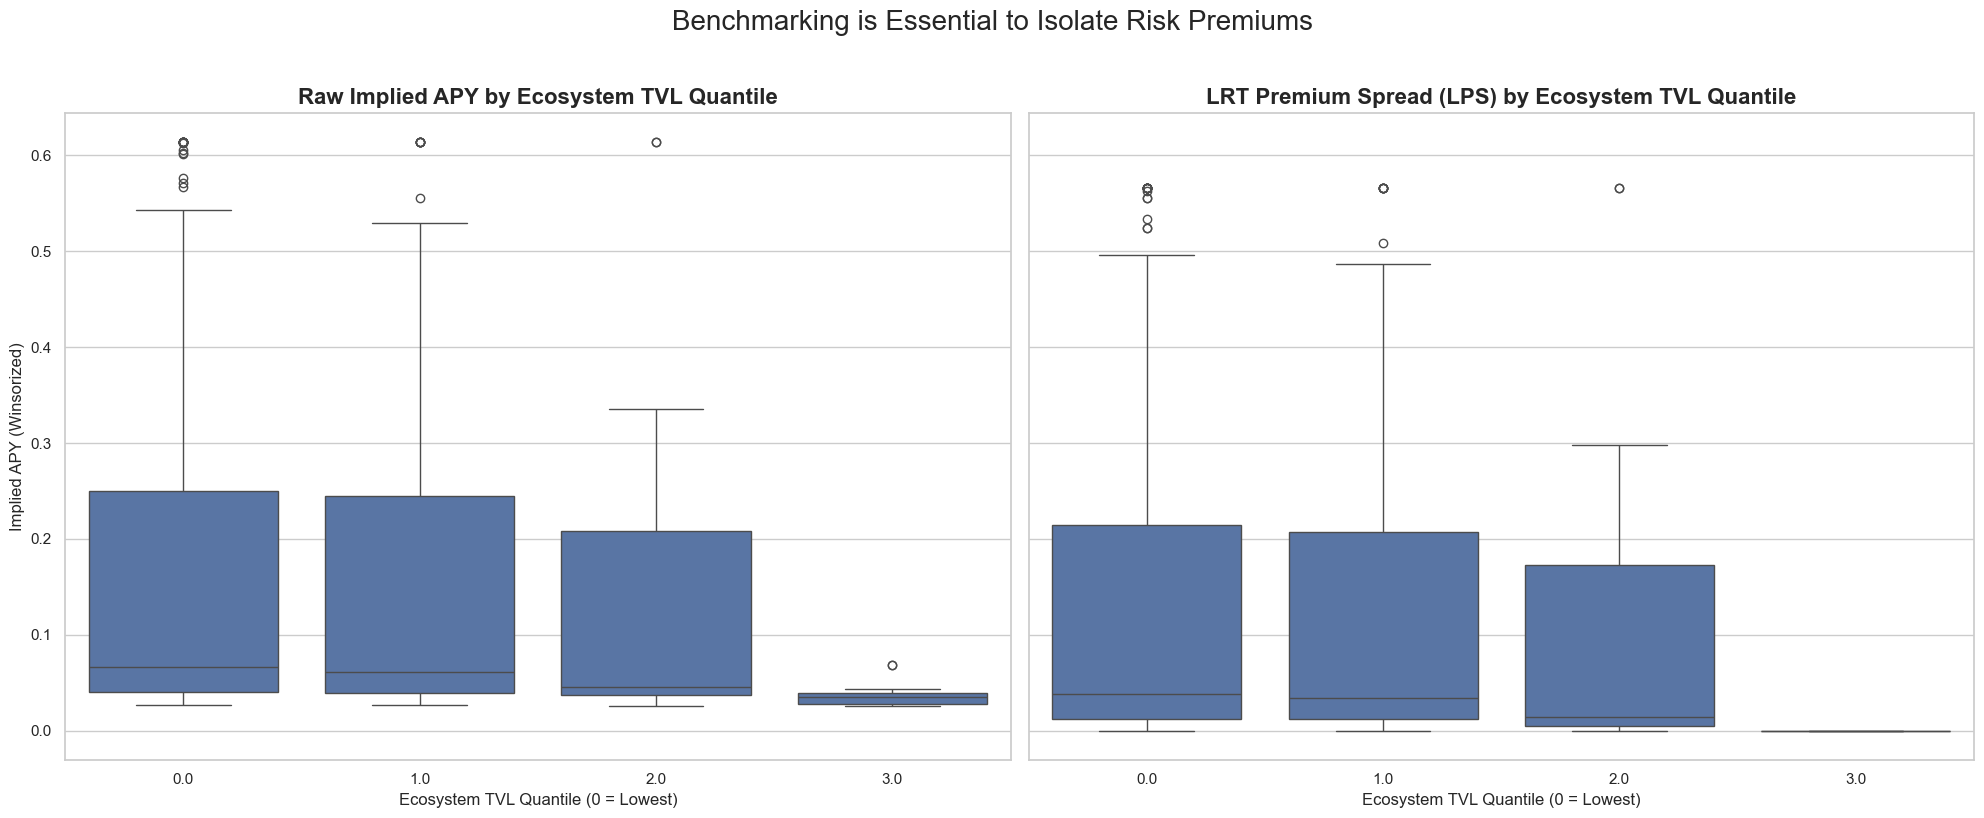


--- Statistical Tests for LPS by TVL Quantile ---
Kruskal-Wallis Test for LPS: H-stat = 737.86, p-value = 1.30e-159
Conover's Post-Hoc Test for LPS:
|          |       0.0 |       1.0 |       2.0 |       3.0 |
|---------:|----------:|----------:|----------:|----------:|
| 0.00e+00 | 1.00e+00  | 2.44e-01  | 1.10e-21  | 2.91e-191 |
| 1.00e+00 | 2.44e-01  | 1.00e+00  | 1.19e-14  | 6.26e-163 |
| 2.00e+00 | 1.10e-21  | 1.19e-14  | 1.00e+00  | 1.37e-110 |
| 3.00e+00 | 2.91e-191 | 6.26e-163 | 1.37e-110 | 1.00e+00  |

--- Generating Figure 2: Bridged Token Case Study (weETH variants) ---


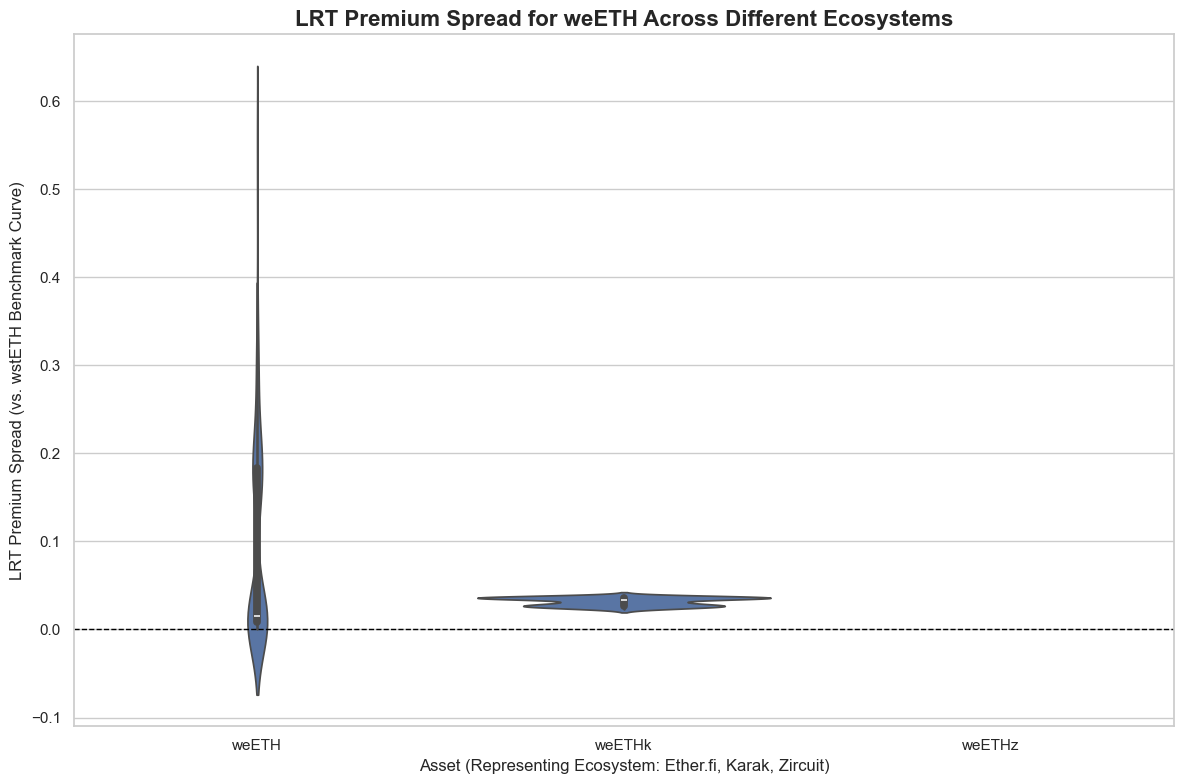


--- Summary Statistics for weETH variants ---
| protocol_asset_raw   |    count |   unique |    top |   freq |
|:---------------------|---------:|---------:|-------:|-------:|
| weETH                | 363.0000 | 312.0000 | 0.0056 | 6.0000 |
| weETHk               |  61.0000 |  44.0000 | 0.0364 | 5.0000 |

--- Generating Figure 3: Comprehensive Comparison of LPS Across All Major LRTs ---


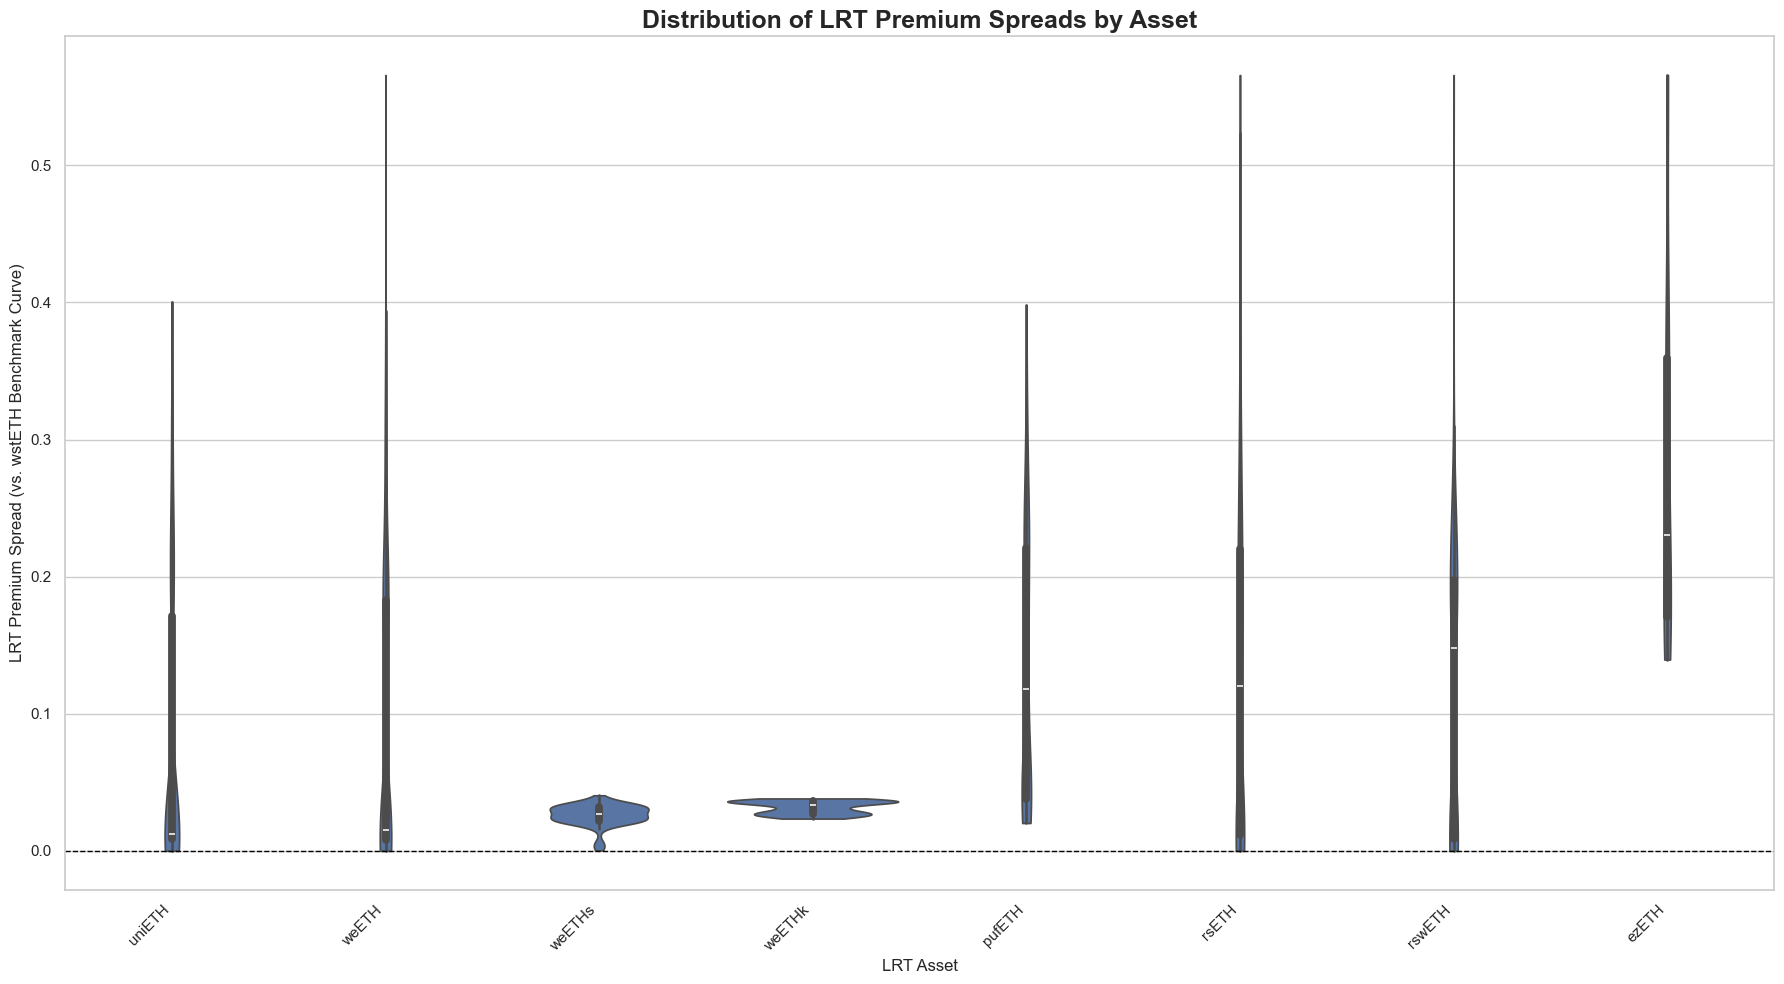


--- Overall Summary Statistics of LPS by LRT ---
| protocol_asset_raw   |    count |   unique |    top |   freq |
|:---------------------|---------:|---------:|-------:|-------:|
| ezETH                |  93.0000 |  91.0000 | 0.1417 | 2.0000 |
| pufETH               | 122.0000 | 121.0000 | 0.0269 | 2.0000 |
| rsETH                | 298.0000 | 234.0000 | 0.0105 | 6.0000 |
| rswETH               | 128.0000 | 111.0000 | 0.0087 | 5.0000 |
| uniETH               | 205.0000 | 170.0000 | 0.0115 | 5.0000 |
| weETH                | 363.0000 | 312.0000 | 0.0056 | 6.0000 |
| weETHk               |  61.0000 |  44.0000 | 0.0364 | 5.0000 |
| weETHs               |  72.0000 |  60.0000 | 0.0267 | 3.0000 |

--- Generating Figure 4: Term Structure of LPS ---


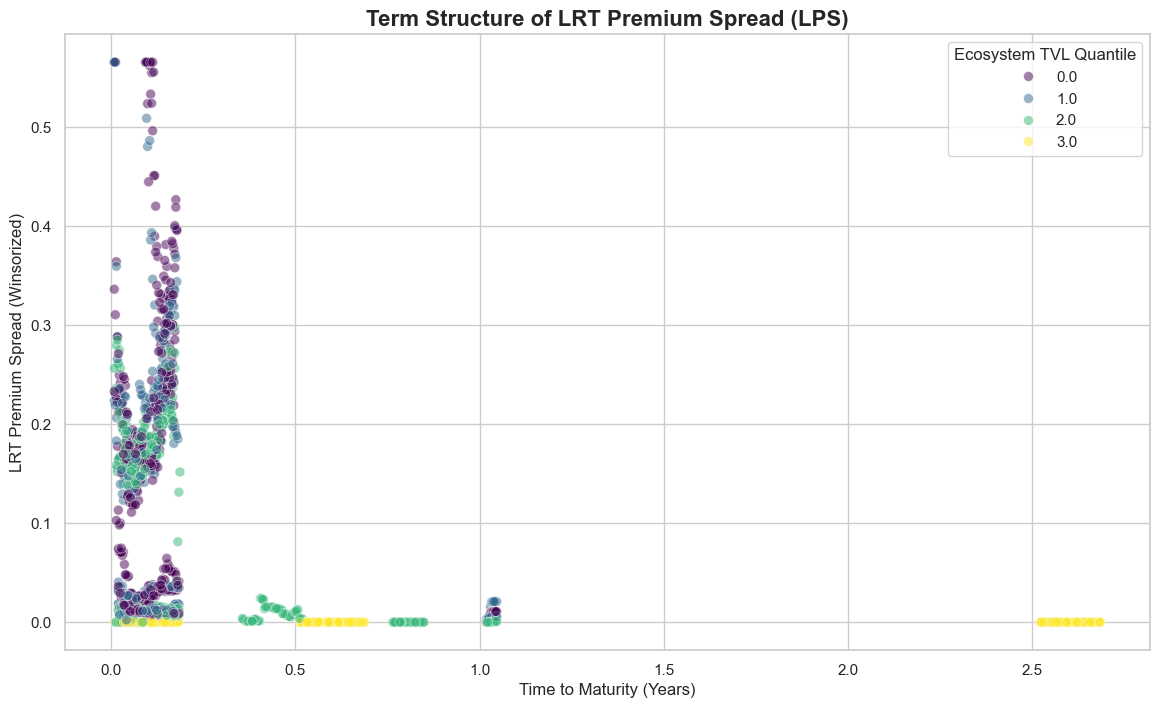

In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import kruskal
import scikit_posthocs as sp

# --- Assume 'master_df' is your fully prepared DataFrame from previous steps ---
# It MUST contain: 'lrt_premium_spread', 'implied_apy', 'TVL_ecosystem', 'chain', 'protocol_asset_raw', 'TTM_years' etc.

# Create the final analysis DataFrame by cleaning
analysis_df = master_df.dropna(subset=['lrt_premium_spread', 'tvl_ecosystem', 'implied_apy']).copy()
analysis_df['tvl_quantile'] = analysis_df.groupby(analysis_df.index.date)['tvl_ecosystem'].transform(
    lambda x: pd.qcut(x, 4, labels=False, duplicates='drop')
)
analysis_df.dropna(subset=['tvl_quantile'], inplace=True)

# Winsorize for plotting
analysis_df['LPS_winsorized'] = analysis_df['lrt_premium_spread'].clip(lower=analysis_df['lrt_premium_spread'].quantile(0.01), upper=analysis_df['lrt_premium_spread'].quantile(0.99))
analysis_df['implied_apy_winsorized'] = analysis_df['implied_apy'].clip(lower=analysis_df['implied_apy'].quantile(0.01), upper=analysis_df['implied_apy'].quantile(0.99))

# --- Set plot style ---
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (14, 8)
print(f"Starting analysis on {len(analysis_df)} data points.")


# ==============================================================================
# FIGURE 1: Raw Implied APY vs. Benchmarked LPS (Justifies Your Metric)
# ==============================================================================
print("\n--- Generating Figure 1: Comparison of Raw APY vs. LPS ---")
fig, axes = plt.subplots(1, 2, figsize=(20, 8), sharey=True)

# Plot 1a: Raw Implied APY vs. TVL
sns.boxplot(ax=axes[0], data=analysis_df, x='tvl_quantile', y='implied_apy_winsorized')
axes[0].set_title('Raw Implied APY by Ecosystem TVL Quantile', fontsize=16, fontweight='bold')
axes[0].set_xlabel('Ecosystem TVL Quantile (0 = Lowest)')
axes[0].set_ylabel('Implied APY (Winsorized)')

# Plot 1b: LRT Premium Spread (LPS) vs. TVL
sns.boxplot(ax=axes[1], data=analysis_df, x='tvl_quantile', y='LPS_winsorized')
axes[1].set_title('LRT Premium Spread (LPS) by Ecosystem TVL Quantile', fontsize=16, fontweight='bold')
axes[1].set_xlabel('Ecosystem TVL Quantile (0 = Lowest)')
axes[1].set_ylabel('LRT Premium Spread (vs. wstETH Benchmark)')

fig.suptitle('Benchmarking is Essential to Isolate Risk Premiums', fontsize=20, y=1.02)
plt.tight_layout()
plt.show()

# Accompanying statistical tests
print("\n--- Statistical Tests for LPS by TVL Quantile ---")
quantiles_lps = [group['LPS_winsorized'].dropna() for name, group in analysis_df.groupby('tvl_quantile')]
kruskal_stat_lps, kruskal_p_lps = kruskal(*quantiles_lps)
print(f"Kruskal-Wallis Test for LPS: H-stat = {kruskal_stat_lps:.2f}, p-value = {kruskal_p_lps:.2e}")
if kruskal_p_lps < 0.05:
    print("Conover's Post-Hoc Test for LPS:")
    print(sp.posthoc_conover(analysis_df, val_col='LPS_winsorized', group_col='tvl_quantile').to_markdown(floatfmt=".2e"))


# ==============================================================================
# FIGURE 2: Bridged Token Case Study (Proves LPS captures ecosystem value)
# ==============================================================================
print("\n--- Generating Figure 2: Bridged Token Case Study (weETH variants) ---")
bridged_assets = ['weETH', 'weETHk', 'weETHz']
bridged_analysis_df = analysis_df[analysis_df['protocol_asset_raw'].isin(bridged_assets)].copy()

if not bridged_analysis_df.empty:
    plt.figure(figsize=(12, 8))
    sns.violinplot(data=bridged_analysis_df, x='protocol_asset_raw', y='LPS_winsorized', 
                   order=bridged_assets)
    plt.axhline(0, color='black', linestyle='--', linewidth=1)
    plt.title('LRT Premium Spread for weETH Across Different Ecosystems', fontsize=16, fontweight='bold')
    plt.xlabel('Asset (Representing Ecosystem: Ether.fi, Karak, Zircuit)')
    plt.ylabel('LRT Premium Spread (vs. wstETH Benchmark Curve)')
    plt.tight_layout()
    plt.show()
    
    print("\n--- Summary Statistics for weETH variants ---")
    print(bridged_analysis_df.groupby('protocol_asset_raw')['lrt_premium_spread'].describe().to_markdown(floatfmt=".4f"))
else:
    print("Not enough data for bridged token analysis.")


# ==============================================================================
# FIGURE 3: Comprehensive Comparison of LPS Across All Major LRTs
# ==============================================================================
print("\n--- Generating Figure 3: Comprehensive Comparison of LPS Across All Major LRTs ---")
plt.figure(figsize=(18, 10))
# Exclude the benchmark itself for clarity
plot_df = analysis_df[analysis_df['protocol_asset_raw'] != 'wstETH']
# Order by median LPS for a better visual story
order = plot_df.groupby('protocol_asset_raw')['LPS_winsorized'].median().sort_values().index
sns.violinplot(data=plot_df, x='protocol_asset_raw', y='LPS_winsorized', order=order, cut=0) # cut=0 prevents tails going below min
plt.axhline(0, color='black', linestyle='--', linewidth=1)
plt.title('Distribution of LRT Premium Spreads by Asset', fontsize=18, fontweight='bold')
plt.xlabel('LRT Asset')
plt.ylabel('LRT Premium Spread (vs. wstETH Benchmark Curve)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Accompanying summary table
print("\n--- Overall Summary Statistics of LPS by LRT ---")
print(analysis_df.groupby('protocol_asset_raw')['lrt_premium_spread'].describe().drop('wstETH', errors='ignore').to_markdown(floatfmt=".4f"))


# ==============================================================================
# FIGURE 4: Term Structure of the LRT Premium Spread
# ==============================================================================
print("\n--- Generating Figure 4: Term Structure of LPS ---")
plt.figure()
sample_df = analysis_df.sample(n=min(10000, len(analysis_df)), random_state=42)
sns.scatterplot(data=sample_df, x='ttm_years', y='LPS_winsorized', hue='tvl_quantile', palette='viridis', alpha=0.5, s=50)
plt.title('Term Structure of LRT Premium Spread (LPS)', fontsize=16, fontweight='bold')
plt.xlabel('Time to Maturity (Years)')
plt.ylabel('LRT Premium Spread (Winsorized)')
plt.legend(title='Ecosystem TVL Quantile')
plt.show()